# 01 — Theory: From ML to DL

**Not alma hedefi:** Her alt başlık için 3–5 maddelik özet + küçük çizimler.

**Mini deney:** Tek-parametreli modelde (y ≈ w x) GD ile MSE minimizasyonu.

**Kıyas:** Aynı oyuncak veride `sklearn.LinearRegression` vs tek katmanlı `y=wx`.

## 1) ML → DL Geçişinin Özeti

**Klasik ML (feature engineering):**
- Özellikler çoğu zaman **elle** çıkarılır (kenar, histogram, istatistikler).
- Az veriyle çalışabilir, CPU ile hızlıdır.
- Tablosal veride güçlü baseline (LogReg, SVM, Tree/GBM).

**Derin Öğrenme (temsil öğrenimi):**
- **Ham veriden** katmanlı olarak **temsil** öğrenir (otomatik feature learning).
- Büyük veri + GPU ile ölçeklenir.
- Görüntü/ses/dil gibi yüksek boyutlu veri alanlarında atılım sağlar.

**Küçük çizimler (ASCII):**
```
# ML yaklaşımı (elle özellik):
X (ham) ──[feature engineering]──> φ(X) ──[ML]──> y

# DL yaklaşımı (katmanlı temsil):
X ──[W1 + act]──> h1 ──[W2 + act]──> h2 ── ... ──> y
```


## 2) Aktivasyon Fonksiyonları — 1 cümlelik özetler
- **Sigmoid:** 0–1 aralığına sıkıştırır; binary sınıflamada çıkışta kullanılır, derin katmanlarda doygunluk riski vardır.
- **Tanh:** −1–1 aralığına merkezler; sigmoid’e göre daha simetriktir, yine doygunluk yaşayabilir.
- **ReLU:** `max(0, x)` ile pozitifleri geçirir; derin ağları hızlandırır, “ölü nöron” riski taşır.
- **Leaky ReLU:** Negatif bölgede küçük eğim vererek ReLU’nun ölü nöron sorununu hafifletir.
- **Softmax:** Çok sınıflı sınıflandırmada logit’leri olasılığa dönüştürür (sınıf dağılımı).

## 3) Overfitting sinyali ve öğrenme oranı
- **Loss ↓ ama val_loss ↑** ise: Model eğitime **aşırı uyum** sağlar (overfitting), genelleme kötüleşir.
- **Öğrenme oranı (η) çok büyük:** Adımlar hedefi ıskalar, **dalgalanma/ildeivergens** görülebilir.
- **Öğrenme oranı çok küçük:** Yavaş yakınsama; eğitim süresi uzar, yerel minimum civarında **sürünme** olur.

## 4) Mini GD Deneyi — y ≈ w x

True w = 2.800, Learned w = 2.799, Final MSE = 0.1244


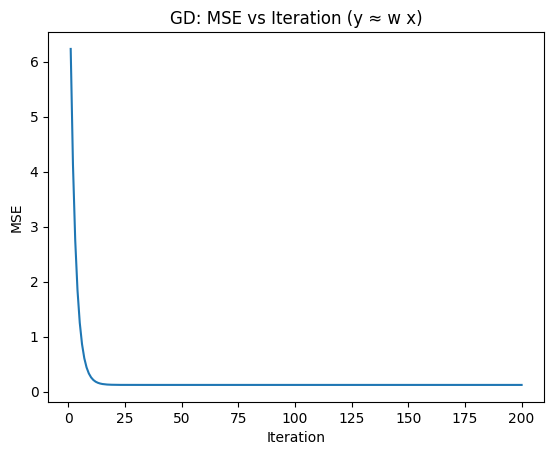

In [9]:

# Mini deney: y ≈ w x tek-parametreli modelde MSE'yi GD ile minimize edelim.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Sentetik veri: y = w_true * x + noise (bias = 0)
n = 120
w_true = 2.8
x = rng.uniform(-2, 2, size=n)
noise = rng.normal(0, 0.35, size=n)
y = w_true * x + noise

# Model: y_hat = w * x
def mse(w):
    y_hat = w * x
    return np.mean((y - y_hat) ** 2)

def grad_mse(w):
    # d/dw (1/n * Σ (y - w x)^2) = -2/n * Σ x (y - w x)
    return (-2.0 / len(x)) * np.sum(x * (y - w * x))

w = 0.0
eta = 0.08  # öğrenme oranı
iters = 200

hist_w, hist_loss = [], []
for t in range(iters):
    g = grad_mse(w)
    w = w - eta * g
    hist_w.append(w)
    hist_loss.append(mse(w))

print(f"True w = {w_true:.3f}, Learned w = {w:.3f}, Final MSE = {hist_loss[-1]:.4f}")

# Tek grafik: loss vs iteration
plt.figure()
plt.plot(np.arange(1, iters+1), hist_loss)
plt.title("GD: MSE vs Iteration (y ≈ w x)")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.show()


## 5) Karşılaştırma — LinearRegression vs Tek Parametreli Model

In [10]:

# Karşılaştırma: sklearn LinearRegression vs tek-parametreli 'y = w x'
import numpy as np
from sklearn.linear_model import LinearRegression

# Aynı veriyi kullanalım (x, y); LinearRegression intercept'li çalışır.
X = x.reshape(-1, 1)

lin = LinearRegression()  # varsayılan: fit_intercept=True
lin.fit(X, y)
w_lr = lin.coef_[0]
b_lr = lin.intercept_

# Bizim model: yalnızca w, bias = 0
w_gd = hist_w[-1]
b_gd = 0.0

print(f"LinearRegression  -> w = {w_lr:.3f}, b = {b_lr:.3f}")
print(f"GD (y=wx, b=0)   -> w = {w_gd:.3f}, b = {b_gd:.3f}")

# Çıkarım farkları (kısa not):
# - LinearRegression, kapalı form/OLS (veya eşdeğeri) ile w ve b'yi birlikte uydurur.
# - Bizim tek-parametreli model, b=0 varsayar; veri gerçek dünyada b≠0 ise hatayı büyütür.
# - Sonuç: aynı veri üzerinde intercept kullanımı performansı ve parametreleri belirgin etkiler.


LinearRegression  -> w = 2.799, b = -0.003
GD (y=wx, b=0)   -> w = 2.799, b = 0.000


## 6) Kontrol Listesi
- [ ] Aktivasyonları 1 cümleyle özetleyebiliyorum.
- [ ] “Loss ↓ ama val_loss ↑” → overfitting ve nedenlerini açıklayabiliyorum.
- [ ] Öğrenme oranı çok büyük/çok küçük olduğunda ne olacağını anlatabiliyorum.
- [ ] LinearRegression (w, b) ile tek-parametreli (yalnızca w) modelin farklarını açıklayabiliyorum.

**Kısa ASCII nöron/kategori çizimi:**
```
(x1, x2, ... , xd) ──> [ Σ w_i x_i + b ] ──act──> h
h1, h2, ... ────> ... ────> y
```
